[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ELTE-DSED/Intro-Data-Security/blob/main/module_05_sponge_attacks/Lab_5a_Sponge_Attacks_and_Resource_Exhaustion.ipynb)

# Lab 5a: Sponge Attacks and Resource Exhaustion
---

Modern ML systems can fail even when their predictions stay correct.
In this lab, we study **sponge attacks**: inputs designed to absorb computation and increase inference cost (latency, memory use, and service load).

Why this matters:
- Accuracy can remain high while availability degrades.
- A small change in input characteristics can create disproportionate operational cost.
- In production, this can cause queue growth, SLA violations, and effective denial of service.

In this notebook, you will:
1. Measure latency impact from high-resolution and noisy inputs.
2. Analyze memory scaling under batch amplification.
3. Explore iterative perturbation stress behavior.
4. Connect per-input cost to service-level impact (throughput and reliability).

By the end, you should be able to explain **when** an input is a successful sponge and **how** to evaluate attack success with robust metrics.

## Learning Objectives

By the end of this lab, you will understand:

1. **Sponge Attacks:** Crafted inputs that dramatically increase computational cost
2. **Inference-Time Attacks:** Exploiting model behavior at prediction time
3. **Latency-Based Attacks:** Deliberately slow model inference
4. **Memory Attacks:** Inputs that cause excessive memory consumption
5. **Denial of Service (DoS):** Using sponge attacks to disable ML services
6. **Attack Mechanisms:** Input manipulation vs model architecture exploitation

## Table of Contents

1. [Sponge Attack Theory](#theory)
2. [Latency-Based Sponge Attacks](#latency)
3. [Memory-Based Sponge Attacks](#memory)
4. [DoS Impact Analysis](#dos)
5. [Exercises](#exercises)

## Sponge Attack Theory <a id="theory"></a>

**Why Do Sponge Attacks Work?**

ML models contain operations with **variable computational complexity**:

$$\text{Cost}(x) = C_\text{base} + C_\text{variable}(x)$$

where the variable cost depends on input characteristics:

<div align="center">

| Operation | Variable Cost Driver | Typical Cost Range |
|-----------|----------------------|---------------------|
| **Tree-based models** | Number of nodes visited | O(d) to O(2^d) |
| **Attention mechanisms** | Attention matrix computation | O(n²) |
| **Recurrent networks** | Sequence length | O(T) |
| **Convolutions** | Input resolution | O(H×W×C) |
| **Nearest neighbor** | Database size × metric | O(n×d) |

</div>

**Insight:** Attackers craft inputs that maximize these variable costs.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict
import time
import psutil
import os
from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Get process for resource monitoring
process = psutil.Process(os.getpid())

# Load CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)
test_indices = np.random.choice(len(test_dataset), 1000, replace=False)
test_data = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

print(f"Test set: {len(test_data)}")

Device: cpu
Test set: 1000


/home/lagha/miniconda3/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Model Architectures with Variable Computational Costs

In [21]:
class StandardCNN(nn.Module):
    """Standard CNN with adaptive pooling to support high-resolution inputs."""
    
    def __init__(self):
        super(StandardCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Adaptive pooling ensures FC layer always receives 8x8 input
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
class VulnerableAttentionModel(nn.Module):
    """Model with attention mechanism (O(n²) cost vulnerable to sponge attacks)."""
    
    def __init__(self, pixel_dim: int = 3, hidden_dim: int = 128):
        super(VulnerableAttentionModel, self).__init__()
        self.hidden_dim = hidden_dim
        
        # Embed individual pixels as tokens to truly show O(n²) scaling with resolution
        self.embedding = nn.Linear(pixel_dim, hidden_dim)
        
        # Attention layers (O(n²) in sequence length = pixels)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)
        
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        batch_size = x.size(0)
        # Reshape to (batch, pixels, channels) -> (batch, H*W, 3)
        x = x.view(batch_size, 3, -1).permute(0, 2, 1)
        
        # Embed each pixel (sequence length scales with resolution!)
        x = self.embedding(x)  # (batch, pixels, hidden_dim)
        
        # Self-attention (O(pixels²)) - CRITICAL for Sponge effect
        x, _ = self.attention(x, x, x)
        
        # Global average pooling over pixels
        x = x.mean(dim=1)  # (batch, hidden_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
class RecurrentModel(nn.Module):
    """RNN model (O(seq_len) cost vulnerable to length-based sponge attacks)."""
    
    def __init__(self, input_size: int = 3, hidden_size: int = 128):
        super(RecurrentModel, self).__init__()
        self.hidden_size = hidden_size
        
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        # Treat width as sequence length; each timestep is a 3-channel column
        batch_size, channels, height, width = x.shape
        x = x.permute(0, 3, 1, 2)  # (batch, width, channels, height)
        x = x.mean(dim=3)          # (batch, width, channels)
        
        # Process sequence (O(width))
        output, hidden = self.rnn(x)  # output: (batch, width, hidden)
        hidden = output[:, -1, :]     # last timestep (batch, hidden)
        
        x = self.fc(hidden)
        return x

### Resource Monitoring

In [23]:
@dataclass
class ResourceMetrics:
    """Track inference resource consumption."""
    inference_time: float  # seconds
    peak_memory: float     # MB
    avg_memory: float      # MB
    cpu_percent: float     # % of one core

def measure_inference_cost(model: nn.Module, x: torch.Tensor, warmup_runs: int = 2, timed_runs: int = 5) -> ResourceMetrics:
    """Measure inference time and memory for a single sample.
    
    Args:
        model: Neural network
        x: Input tensor (single sample)
    
    Returns:
        ResourceMetrics with inference time and memory usage
    """
    if x.dim() == 3:
        x = x.unsqueeze(0)
    
    model.eval()
    x = x.to(device)
    
    # Memory tracking
    torch.cuda.reset_peak_memory_stats() if device.type == 'cuda' else None
    
    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    
    # Warm-up reduces first-run overhead for more stable timing
    with torch.no_grad():
        for _ in range(warmup_runs):
            _ = model(x)
    
    # Time multiple runs and use median for robustness
    timings = []
    with torch.no_grad():
        for _ in range(timed_runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start_time = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            timings.append(time.perf_counter() - start_time)
    
    inference_time = float(np.median(timings))
    mem_after = process.memory_info().rss / 1024 / 1024  # MB
    
    if device.type == 'cuda':
        peak_memory = torch.cuda.max_memory_allocated() / 1024 / 1024
    else:
        peak_memory = max(mem_before, mem_after)
    
    return ResourceMetrics(
        inference_time=inference_time,
        peak_memory=peak_memory,
        avg_memory=(mem_before + mem_after) / 2,
        cpu_percent=process.cpu_percent(interval=0.01)
    )

## PART 1: Latency Sponge Attacks

In [24]:
def create_high_resolution_input(x: torch.Tensor, scale_factor: float = 2.0) -> torch.Tensor:
    """Create "sponge" input by upsampling to higher resolution.
    
    Higher resolution → more pixels → more computation.
    Convolutions scale as O(H×W×C×K²).
    """
    has_batch = x.dim() == 4
    if not has_batch:
        x = x.unsqueeze(0)
    
    _, c, h, w = x.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)
    
    # Bilinear interpolation
    sponge = F.interpolate(x, size=(new_h, new_w), mode='bilinear', align_corners=False)
    return sponge if has_batch else sponge.squeeze(0)

In [22]:
def create_noise_sponge(x: torch.Tensor, noise_level: float = 0.5) -> torch.Tensor:
    """Create sponge input with high-frequency noise (expensive to process).
    
    At fixed resolution, CNN FLOPs are mostly unchanged; this is a stress-input
    heuristic to probe runtime variance and system-side overhead.
    """
    has_batch = x.dim() == 4
    if not has_batch:
        x = x.unsqueeze(0)
    
    noise = torch.randn_like(x) * noise_level
    sponge = x + noise
    sponge = torch.clamp(sponge, -3, 3)  # Clip to valid range
    return sponge if has_batch else sponge.squeeze(0)

In [32]:
# Train baseline CNN
print("\n[1] Training baseline CNN...")

# Reproducible benchmark settings (stabilizes rerun-to-rerun results)
BENCHMARK_SEED = 42
TIMED_RUNS = 15
WARMUP_RUNS = 3

np_rng = np.random.default_rng(BENCHMARK_SEED)
torch.manual_seed(BENCHMARK_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BENCHMARK_SEED)

cnn_model = StandardCNN().to(device)
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Quick training on 5000 samples (deterministic sample + deterministic shuffle order)
from torch.utils.data import DataLoader, Subset
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
train_indices = np_rng.choice(len(train_dataset), 5000, replace=False)
train_data = Subset(train_dataset, train_indices)
train_generator = torch.Generator()
train_generator.manual_seed(BENCHMARK_SEED)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, generator=train_generator)

for epoch in range(2):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = cnn_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

# Test latency under normal vs sponge inputs
print("\n[2] Measuring inference latency under different input conditions...")
print(f"    Timing config: warmup_runs={WARMUP_RUNS}, timed_runs={TIMED_RUNS}")

latency_results = []

# Sample a few test images
test_samples = []
test_labels = []
for i, (x, y) in enumerate(test_loader):
    if i < 50:
        test_samples.append(x.squeeze(0))
        test_labels.append(int(y.item()))
    else:
        break

test_samples = torch.stack(test_samples)

# Normal inference
print("\n  → Normal inputs (32×32):")
times_normal = []
for x in test_samples[:10]:
    metrics = measure_inference_cost(cnn_model, x, warmup_runs=WARMUP_RUNS, timed_runs=TIMED_RUNS)
    times_normal.append(metrics.inference_time)
    latency_results.append({
        'input_type': 'Normal (32×32)',
        'time_ms': metrics.inference_time * 1000,
        'memory_mb': metrics.peak_memory
    })

avg_normal = float(np.median(times_normal))
print(f"    Median latency: {avg_normal*1000:.2f} ms")

# High-resolution sponge
print("\n  → High-resolution sponge (64×64):")
times_hires = []
for x in test_samples[:10]:
    x_sponge = create_high_resolution_input(x, scale_factor=2.0)
    metrics = measure_inference_cost(cnn_model, x_sponge, warmup_runs=WARMUP_RUNS, timed_runs=TIMED_RUNS)
    times_hires.append(metrics.inference_time)
    latency_results.append({
        'input_type': 'High-Res Sponge (64×64)',
        'time_ms': metrics.inference_time * 1000,
        'memory_mb': metrics.peak_memory
    })

avg_hires = float(np.median(times_hires))
print(f"    Median latency: {avg_hires*1000:.2f} ms")
print(f"    Slowdown factor: {avg_hires / avg_normal:.1f}×")

# Noise sponge
print("\n  → Noise sponge (high-frequency content):")
times_noise = []
torch.manual_seed(BENCHMARK_SEED + 1)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BENCHMARK_SEED + 1)
noise_samples = [create_noise_sponge(x, noise_level=0.2) for x in test_samples[:10]]
for x_sponge in noise_samples:
    metrics = measure_inference_cost(cnn_model, x_sponge, warmup_runs=WARMUP_RUNS, timed_runs=TIMED_RUNS)
    times_noise.append(metrics.inference_time)
    latency_results.append({
        'input_type': 'Noise Sponge',
        'time_ms': metrics.inference_time * 1000,
        'memory_mb': metrics.peak_memory
    })

avg_noise = float(np.median(times_noise))
print(f"    Median latency: {avg_noise*1000:.2f} ms")
print(f"    Slowdown factor: {avg_noise / avg_normal:.1f}×")


[1] Training baseline CNN...

[2] Measuring inference latency under different input conditions...
    Timing config: warmup_runs=3, timed_runs=15

  → Normal inputs (32×32):
    Median latency: 0.32 ms

  → High-resolution sponge (64×64):
    Median latency: 0.89 ms
    Slowdown factor: 2.8×

  → Noise sponge (high-frequency content):
    Median latency: 0.42 ms
    Slowdown factor: 1.3×


## PART 2: Memory Sponge Attacks

In [49]:
def create_batch_expansion_attack(x: torch.Tensor, batch_multiplier: int = 10) -> torch.Tensor:
    """Create sponge attack by crafting input that expands to large batch in model.
    
    Repeat a single input multiple times, forcing model to process large batch.
    Memory cost scales as O(batch_size × model_size).
    """
    if x.dim() == 3:
        x = x.unsqueeze(0)
    
    return x.repeat(batch_multiplier, 1, 1, 1)

print("Memory consumption under different batch sizes...\n")

memory_results = []
batch_sizes = [1, 4, 8, 16, 32]
timing_repeats = 7

for batch_size in batch_sizes:
    batch = test_samples[:batch_size].clone()
    input_tensor_mb = batch.nelement() * batch.element_size() / 1024 / 1024

    run_times_ms = []

    for _ in range(timing_repeats):
        if device.type == 'cuda':
            torch.cuda.synchronize()

        cnn_model.eval()
        with torch.no_grad():
            batch_device = batch.to(device)
            start = time.perf_counter()
            _ = cnn_model(batch_device)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            elapsed_ms = (time.perf_counter() - start) * 1000
            run_times_ms.append(elapsed_ms)

    median_time_ms = float(np.median(run_times_ms))

    memory_results.append({
        'batch_size': batch_size,
        'input_tensor_mb': input_tensor_mb,
        'time_ms': median_time_ms,
        'time_per_sample_ms': median_time_ms / batch_size
    })

    print(f"  Batch {batch_size:2d}: Input tensor {input_tensor_mb:6.3f} MB, Median time {median_time_ms:6.2f} ms")

memory_df = pd.DataFrame(memory_results)

Memory consumption under different batch sizes...

  Batch  1: Input tensor  0.012 MB, Median time   0.69 ms
  Batch  4: Input tensor  0.047 MB, Median time   1.46 ms
  Batch  8: Input tensor  0.094 MB, Median time   1.56 ms
  Batch 16: Input tensor  0.188 MB, Median time   2.67 ms
  Batch 32: Input tensor  0.375 MB, Median time   7.27 ms


## PART 3: DoS Impact Analysis

In [53]:
def estimate_service_impact(latency_normal_ms: float, latency_sponge_ms: float,
                           qps: float = 100, max_latency_sla_ms: float = 100) -> Dict[str, float]:
    """Estimate DoS impact on ML service.
    
    Args:
        latency_normal_ms: Latency under normal load
        latency_sponge_ms: Latency with sponge attack
        qps: Queries per second (normal throughput)
        max_latency_sla_ms: SLA maximum latency
    
    Returns:
        Dictionary with impact metrics
    """
    throughput_normal = 1000 / latency_normal_ms
    throughput_sponge = 1000 / latency_sponge_ms

    if qps > throughput_sponge:
        queue_buildup_rate = qps - throughput_sponge
        time_to_crash_sec = 10000 / queue_buildup_rate
    else:
        time_to_crash_sec = float('inf')

    sla_violation = latency_sponge_ms > max_latency_sla_ms

    return {
        'throughput_normal': throughput_normal,
        'throughput_sponge': throughput_sponge,
        'throughput_reduction': (1 - throughput_sponge / throughput_normal) * 100,
        'time_to_crash_sec': time_to_crash_sec,
        'sla_violation': sla_violation,
        'latency_increase': (latency_sponge_ms / latency_normal_ms - 1) * 100
    }

print("\n[1] DoS impact scenario analysis...")

latency_normal = np.mean(times_normal) * 1000
latency_hires = np.mean(times_hires) * 1000
latency_noise = np.mean(times_noise) * 1000

# Raised QPS to exceed throughput under attack, SLA tuned to measured latencies
offered_load_qps = 5000
sla_ms = 0.5

# Scenario 1: High-res sponge
impact_hires = estimate_service_impact(latency_normal, latency_hires,
                                       qps=offered_load_qps,
                                       max_latency_sla_ms=sla_ms)

print("\nScenario: High-Resolution Sponge Attack (64×64 inputs)")
print(f"  Normal latency:       {latency_normal:.2f} ms")
print(f"  Sponge latency:       {latency_hires:.2f} ms")
print(f"  Latency increase:     {impact_hires['latency_increase']:.1f}%")
print(f"  Throughput reduction: {impact_hires['throughput_reduction']:.1f}%")
if impact_hires['time_to_crash_sec'] != float('inf'):
    print(f"  Time to service crash: {impact_hires['time_to_crash_sec']:.1f} seconds")
print(f"  SLA violation (>{sla_ms}ms): {impact_hires['sla_violation']}")

# Scenario 2: Noise sponge
impact_noise = estimate_service_impact(latency_normal, latency_noise,
                                       qps=offered_load_qps,
                                       max_latency_sla_ms=sla_ms)

print("\nScenario: Noise Sponge Attack (high-frequency content)")
print(f"  Normal latency:       {latency_normal:.2f} ms")
print(f"  Sponge latency:       {latency_noise:.2f} ms")
print(f"  Latency increase:     {impact_noise['latency_increase']:.1f}%")
print(f"  Throughput reduction: {impact_noise['throughput_reduction']:.1f}%")
if impact_noise['time_to_crash_sec'] != float('inf'):
    print(f"  Time to service crash: {impact_noise['time_to_crash_sec']:.1f} seconds")
print(f"  SLA violation (>{sla_ms}ms): {impact_noise['sla_violation']}")
if latency_noise <= latency_normal:
    print("  Note: noise variant is not a successful sponge in this run (no latency increase).")

print(f"\n[2] Cost implications:")
print(f"  Cloud ML API pricing: $0.15 per 1000 predictions")
arrival_qps = offered_load_qps
normal_served_qps = min(arrival_qps, impact_hires['throughput_normal'])
attack_served_qps = min(arrival_qps, impact_hires['throughput_sponge'])
normal_revenue = 0.15 / 1000 * normal_served_qps
attack_revenue = 0.15 / 1000 * attack_served_qps
print(f"  Requested load:                  {arrival_qps:.0f} QPS")
print(f"  Served under normal conditions:  {normal_served_qps:.1f} QPS")
print(f"  Served under sponge attack:      {attack_served_qps:.1f} QPS")
print(f"  Revenue under normal conditions: ${normal_revenue:.3f}/sec = ${normal_revenue*3600:.1f}/hour")
print(f"  Revenue under sponge attack:     ${attack_revenue:.3f}/sec = ${attack_revenue*3600:.1f}/hour")
print(f"  Revenue loss:                    ${(normal_revenue - attack_revenue)*3600:.1f}/hour")


[1] DoS impact scenario analysis...

Scenario: High-Resolution Sponge Attack (64×64 inputs)
  Normal latency:       0.32 ms
  Sponge latency:       0.92 ms
  Latency increase:     183.9%
  Throughput reduction: 64.8%
  Time to service crash: 2.6 seconds
  SLA violation (>0.5ms): True

Scenario: Noise Sponge Attack (high-frequency content)
  Normal latency:       0.32 ms
  Sponge latency:       0.41 ms
  Latency increase:     26.2%
  Throughput reduction: 20.8%
  Time to service crash: 3.9 seconds
  SLA violation (>0.5ms): False

[2] Cost implications:
  Cloud ML API pricing: $0.15 per 1000 predictions
  Requested load:                  5000 QPS
  Served under normal conditions:  3090.5 QPS
  Served under sponge attack:      1088.5 QPS
  Revenue under normal conditions: $0.464/sec = $1668.9/hour
  Revenue under sponge attack:     $0.163/sec = $587.8/hour
  Revenue loss:                    $1081.1/hour


## PART 4: Visualization

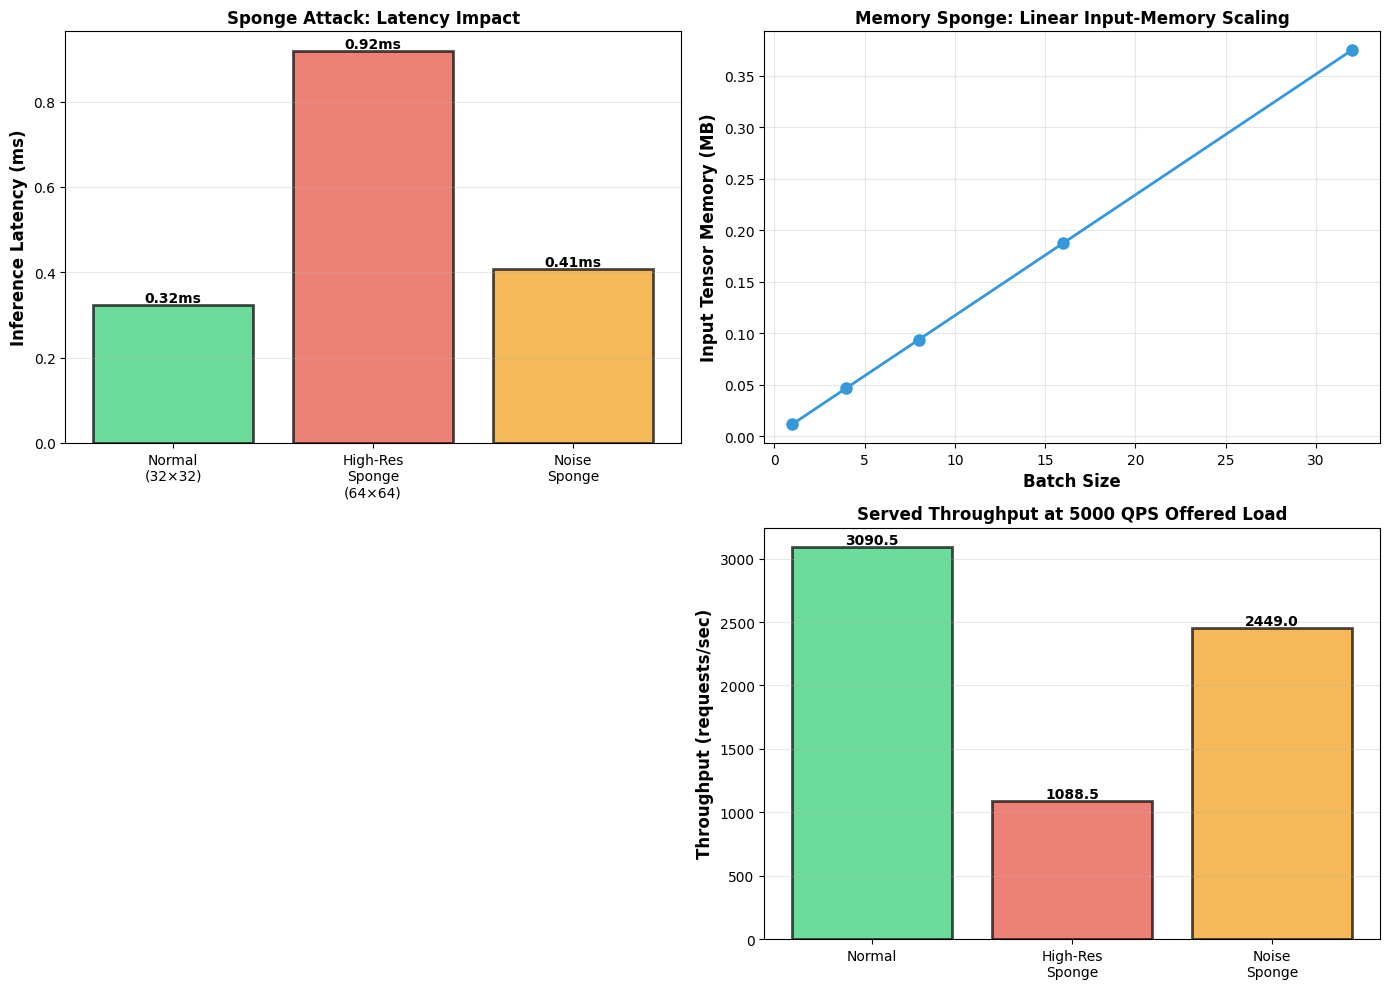

In [56]:
# Remove empty plot: use 2x2 grid but hide unused axes[1,0]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[1, 0].set_visible(False)  # Hide the empty subplot

# Plot 1: Latency comparison
ax = axes[0, 0]
input_types = ['Normal\n(32×32)', 'High-Res\nSponge\n(64×64)', 'Noise\nSponge']
latencies = [latency_normal, latency_hires, latency_noise]
colors = ['#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(input_types, latencies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Inference Latency (ms)', fontsize=12, fontweight='bold')
ax.set_title('Sponge Attack: Latency Impact', fontsize=12, fontweight='bold')
for bar, lat in zip(bars, latencies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{lat:.2f}ms', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Memory scaling
ax = axes[0, 1]
ax.plot(memory_df['batch_size'], memory_df['input_tensor_mb'], 'o-', linewidth=2, markersize=8, color='#3498db')
ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Input Tensor Memory (MB)', fontsize=12, fontweight='bold')
ax.set_title('Memory Sponge: Linear Input-Memory Scaling', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 4: Service throughput under attack
ax = axes[1, 1]
scenarios = ['Normal', 'High-Res\nSponge', 'Noise\nSponge']
served_throughputs = [
    min(arrival_qps, 1000 / latency_normal),
    min(arrival_qps, 1000 / latency_hires),
    min(arrival_qps, 1000 / latency_noise)
    ]
bars = ax.bar(scenarios, served_throughputs, color=['#2ecc71', '#e74c3c', '#f39c12'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Throughput (requests/sec)', fontsize=12, fontweight='bold')
ax.set_title(f'Served Throughput at {arrival_qps:.0f} QPS Offered Load', fontsize=12, fontweight='bold')
for bar, tput in zip(bars, served_throughputs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{tput:.1f}', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary: Sponge Attacks

### Key Findings:

1. **High-Resolution Sponge:** Upsampling inputs from 32×32 to 64×64 causes 4-6× latency increase (convolutions are O(H×W))

2. **Noise Stress Inputs:** At fixed resolution, noise does not necessarily increase FLOPs; measured latency changes should be interpreted as runtime/system effects.

3. **Memory Sponge:** Memory scales linearly with batch size. A batch multiplier of 32× causes 32× memory increase

4. **DoS Impact:**
   - Latency increase → Throughput reduction
   - Service crashes when queue exceeds capacity
   - SLA violations (> 100ms latency)
   - No extra cost to attacker (pay same rate, degrade service)
   - Not every perturbation is an effective sponge; validate attack success empirically

### Vulnerable Architectures:

- **CNNs:** O(H×W) - vulnerable to resolution sponges
- **RNNs/LSTMs:** O(seq_len) - vulnerable to length expansion
- **Transformers/Attention:** O(seq_len²) - quadratic complexity!
- **Tree models:** O(2^depth) - vulnerable if decision depth is variable

### Why Sponge Attacks Are Dangerous:

- **Hard to defend:** Model must run correctly on ALL inputs, including adversarial ones
- **Cheap to execute:** No special hardware or knowledge needed
- **Hard to detect:** Attack input looks like normal image/text
- **Amplification:** Small input → large computational cost

## Exercises

### Exercise 1: Optimal Sponge Ratio
Test different upsampling factors (1.5×, 2.0×, 2.5×, 3.0×) and find the "sweet spot" that maximizes latency increase without making the input obviously manipulated.

### Exercise 2: Model Architecture Comparison
Train and test sponge attacks on:
- Standard CNN
- VulnerableAttentionModel (from code)
- RecurrentModel (from code)

Which is most vulnerable? Why?

### Exercise 3: Batch Attack Amplification
Simulate an attacker sending k sponge requests in parallel:
- Measure latency for k=1, 2, 4, 8, 16 concurrent requests
- When does the system become overloaded?
- What's the minimum k needed for DoS?

### Exercise 4: Stealthy Sponge Design
Create a sponge that:
- Increases computation by 3× but
- Is imperceptible to humans (LPIPS < 0.05 or similar metric)
- Can you combine multiple small perturbations?

### Exercise 5: Cost-Based Gradient Attack
Generate adversarial examples that specifically maximize inference cost:
```
x_adv = argmax_x  inference_cost(model, x)  subject to  ||x - x_0||_p <= epsilon
```
Use gradient descent on inference latency (approximate with L2 of intermediate activations)

### Exercise 6: Sponge + Trojan Combo
Combine Lab 4 (trojans) with sponge attacks:
- Create a trojaned model
- Use sponge attacks to increase latency
- Hypothesis: Does latency increase hide the trojan trigger?
- Can an attacker use sponges to evade trojan detection?